Pricing supplement: https://www.sec.gov/Archives/edgar/data/895421/000183988225015267/ms6936_424b2-07888.htm

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import date, datetime
from scipy.interpolate import interp1d

# Dates and Features

In [2]:
pricing_date = date(2025, 3, 10)
issue_date = date(2025, 3, 13)
final_observation_date = date(2026, 12, 10)
maturity_date = date(2026, 12, 15)
redemption_dates = np.array([
    date(2025, 6, 13), date(2025, 9, 15), date(2025, 12, 15),
    date(2026, 3, 13), date(2026, 6, 15), date(2026, 9, 15)
])
observation_dates = np.array([
    date(2025, 4, 10), date(2025, 5, 12), date(2025, 6, 10),
    date(2025, 7, 10), date(2025, 8, 11), date(2025, 9, 10),
    date(2025, 10, 10), date(2025, 11, 10), date(2025, 12, 10),
    date(2026, 1, 12), date(2026, 2, 10), date(2026, 3, 10),
    date(2026, 4, 10), date(2026, 5, 11), date(2026, 6, 10),
    date(2026, 7, 10), date(2026, 8, 10), date(2026, 9, 10),
    date(2026, 10, 12), date(2026, 11, 10), date(2026, 12, 10)
])
coupon_dates = np.array([
    date(2025, 4, 15), date(2025, 5, 15), date(2025, 6, 13),
    date(2025, 7, 15), date(2025, 8, 14), date(2025, 9, 15),
    date(2025, 10, 16), date(2025, 11, 14), date(2025, 12, 15),
    date(2026, 1, 15), date(2026, 2, 13), date(2026, 3, 13),
    date(2026, 4, 15), date(2026, 5, 14), date(2026, 6, 15),
    date(2026, 7, 15), date(2026, 8, 13), date(2026, 9, 15),
    date(2026, 10, 15), date(2026, 11, 16), date(2026, 12, 15)
])

obs_to_coupon = np.array([diff_date.days / 365 for diff_date in (coupon_dates - observation_dates)])

# In sequence of SPX, NDXT, RTY
S0 = np.array([5614.56, 9548.55, 2019.067])
downside_threshold = np.array([3368.736, 5729.13, 1211.440])
coupon_barrier = np.array([3930.192, 6683.985, 1413.347])
coupon_rate = 0.07  # Annual rate
principal = 1000
estimated_value = 953.6  # Estimated value on the pricing date from description

# Parameters of Stocks

In [3]:
# Interest rate and discount rate between pricing date and maturity date
discount = interp1d([datetime(2026, 9, 11).timestamp(), datetime(2027, 3, 11).timestamp()],
            [0.943391, 0.926869], kind='linear')(datetime(2026, 12, 15).timestamp())
r = -np.log(discount) / ((maturity_date - pricing_date).days / 365)

# dates of implied volatility and dates we need
quote_dates = np.array([datetime(2025, 4, 10).timestamp(), datetime(2025, 6, 10).timestamp(), datetime(2025, 9, 10).timestamp(),
        datetime(2025, 12, 10).timestamp(), datetime(2026, 3, 10).timestamp(), datetime(2026, 6, 10).timestamp(),
        datetime(2026, 9, 10).timestamp(), datetime(2026, 12, 10).timestamp(), datetime(2027, 3, 10).timestamp()])
target_dates = np.array([datetime(2025, 6, 10).timestamp(), datetime(2025, 9, 10).timestamp(), datetime(2025, 12, 10).timestamp(),
        datetime(2026, 3, 10).timestamp(), datetime(2026, 6, 10).timestamp(), datetime(2026, 9, 10).timestamp(), datetime(2026, 12, 10).timestamp()])

# volatility vector corresponding to downside threshhold
sigma_spx_vec_downside = interp1d(quote_dates, [0.72696, 0.51517, 0.42055, 0.37504, 0.34673, 0.32646, 0.31182, 0.30078, 0.29219], kind='linear')
sigma_spx_dowside = sigma_spx_vec_downside(target_dates)
sigma_ndxt_vec_downside = interp1d(quote_dates, [0.31887, 0.27612, 0.27449, 0.25533, 0.24550, 0.24379, 0.24379, 0.24379, 0.24379], kind='linear')
sigma_ndxt_dowside = sigma_ndxt_vec_downside(target_dates)
sigma_rty_vec_downside = interp1d(quote_dates, [0.41251, 0.49521, 0.41406, 0.39407, 0.35803, 0.35139, 0.33552, 0.32176, 0.31565], kind='linear')
sigma_rty_dowside = sigma_rty_vec_downside(target_dates)
sigma_downside = np.array([sigma_spx_dowside[-1], sigma_ndxt_dowside[-1], sigma_rty_dowside[-1]])
sigma_avg_downside = np.array([sigma_spx_dowside.mean(), sigma_ndxt_dowside.mean(), sigma_rty_dowside.mean()])

# volatility vector corresponding to coupon barrier
sigma_spx_vec_barrier = interp1d(quote_dates, [0.57480, 0.42183, 0.35024, 0.31769, 0.29775, 0.28419, 0.27501, 0.26937, 0.26427], kind='linear')
sigma_spx_barrier = sigma_spx_vec_barrier(target_dates)
sigma_ndxt_vec_barrier = interp1d(quote_dates, [0.31887, 0.27612, 0.27449, 0.25533, 0.24550, 0.24379, 0.24379, 0.24379, 0.24379], kind='linear')
sigma_ndxt_barrier = sigma_ndxt_vec_barrier(target_dates)
sigma_rty_vec_barrier = interp1d(quote_dates, [0.41490, 0.43270, 0.36669, 0.34411, 0.31560, 0.31274, 0.30107, 0.29120, 0.28716], kind='linear')
sigma_rty_barrier = sigma_rty_vec_barrier(target_dates)
sigma_barrier = np.array([sigma_spx_barrier[-1], sigma_ndxt_barrier[-1], sigma_rty_barrier[-1]])
sigma_avg_barrier = np.array([sigma_spx_barrier.mean(), sigma_ndxt_barrier.mean(), sigma_rty_barrier.mean()])

# volatility vector corresponding to at-the-money price
sigma_spx_vec_atm = interp1d(quote_dates, [0.23639, 0.20387, 0.19745, 0.19478, 0.19326, 0.19375, 0.19281, 0.19350, 0.19293], kind='linear')
sigma_spx_atm = sigma_spx_vec_atm(target_dates)
sigma_ndxt_vec_atm = interp1d(quote_dates, [0.31887, 0.27612, 0.27449, 0.25533, 0.24550, 0.24379, 0.24379, 0.24379, 0.24379], kind='linear')
sigma_ndxt_atm = sigma_ndxt_vec_atm(target_dates)
sigma_rty_vec_atm = interp1d(quote_dates, [0.30793, 0.26355, 0.25098, 0.24937, 0.23867, 0.24206, 0.23764, 0.23459, 0.23517], kind='linear')
sigma_rty_atm = sigma_rty_vec_atm(target_dates)
sigma_atm = np.array([sigma_spx_atm[-1], sigma_ndxt_atm[-1], sigma_rty_atm[-1]])
sigma_avg_atm = np.array([sigma_spx_atm.mean(), sigma_ndxt_atm.mean(), sigma_rty_atm.mean()])

# dividend yield
delta = np.array([0.01439, 0.00628, 0.01548])

# correlation among three stocks
corr_6m = np.array([[1, 0.861, 0.910], [0.861, 1, 0.767], [0.910, 0.767, 1]])
corr_1y = np.array([[1, 0.895, 0.767], [0.895, 1, 0.620], [0.767, 0.620, 1]])
corr_5y = np.array([[1, 0.868, 0.858], [0.868, 1, 0.741], [0.858, 0.741, 1]])

# Monte Carlo Pricer

In [4]:
def simulate_stock_price(N, M, corr, sigma, delta):
  L = np.linalg.cholesky(corr)
  np.random.seed(42)
  Z = np.random.normal(size=(N, M, 3))
  S = np.zeros((N, M+1, 3))
  S[:, 0, :] = S0
  prev_date = pricing_date
  for i in range(M):
    dt = (observation_dates[i] - prev_date).days / 365
    dw = Z[:, i, :].dot(L.T) * np.sqrt(dt)
    S[:, i+1, :] = S[:, i, :] * np.exp((r - delta - 0.5 * sigma**2) * dt + sigma * dw)
    prev_date = observation_dates[i]
  return S


def payment_at_maturity(ST):
  contingent_coupon = np.where((ST>=coupon_barrier).all(axis=1),
                  principal * coupon_rate * (observation_dates[-1]-observation_dates[-2]).days/365,
                  0)
  payment = np.where((ST>=downside_threshold).all(axis=1),
             principal,
             principal * (ST / S0).min(axis=1))
  return payment + contingent_coupon

def legendre_basis(x, k=3):
    B = [np.ones(len(x)), x]
    for n in range(2, k+1):
        Bn = ((2 * n - 1) * x * B[n - 1] - (n - 1) * B[n - 2]) / n
        B.append(Bn)

    return np.column_stack(B)

def chebyshev_basis(x, k=3):
    B = [np.ones(len(x)), x]
    for n in range(2, k+1):
        Bn = 2 * x * B[n - 1] - B[n - 2]
        B.append(Bn)

    return np.column_stack(B)

def Callable_Contingent_pricer(N, r, sigma, delta, corr, basis_key):
  '''
  r1 is the interest rate indicating stock price movement
  r2 is the interest rate indicating time value of money
  sigma is the volatility of stock
  delta is the continuous dividend yield of stock
  N is the number of simulation paths
  '''
  basis_dict = {'Legendre': legendre_basis, 'Chebyshev': chebyshev_basis}
  basis = basis_dict[basis_key]
  M = len(observation_dates)
  S = simulate_stock_price(N, M, corr, sigma, delta)
  discounted_future_value = payment_at_maturity(S[:, -1, :]) * np.exp(-r * obs_to_coupon[-1]) # discount value from coupon date to observation date
  for i in range(M-2, 0, -1):
    # discount future value and contingent coupon to current time
    contingent_coupon = np.where((S[:, i+1, :]>=coupon_barrier).all(axis=1),
                    principal * coupon_rate * (observation_dates[i] - observation_dates[i-1]).days/365,
                    0)
    discounted_future_value = discounted_future_value * np.exp(-r * (observation_dates[i+1] - observation_dates[i]).days / 365) + \
                  contingent_coupon * np.exp(-r * obs_to_coupon[i])
    if coupon_dates[i] in redemption_dates:  # LSMC
      X1 = basis(S[:, i+1, 0])
      X2 = basis(S[:, i+1, 1])
      X3 = basis(S[:, i+1, 2])
      X = np.column_stack([X1, X2[:,1:], X3[:,1:]])
      Y = discounted_future_value
      theta = np.linalg.solve(X.T @ X, X.T @ Y)
      value_if_wait = X @ theta
      #value_if_call = principal * (1 + coupon_rate * (observation_dates[i] - observation_dates[i-1]).days / 365) * np.exp(-r * obs_to_coupon[i])
      value_if_call = (principal + contingent_coupon) * np.exp(-r * obs_to_coupon[i])
      call = value_if_call <= value_if_wait
      discounted_future_value = np.where(call, value_if_call, discounted_future_value)
  # i = 0, get the value on the first observation date
  contingent_coupon = np.where((S[:, 1, :]>=coupon_barrier).all(axis=1),
                  principal * coupon_rate * (observation_dates[0] - pricing_date).days/365,
                  0)
  discounted_future_value = discounted_future_value * np.exp(-r * (observation_dates[1] - observation_dates[0]).days / 365) + \
                contingent_coupon * np.exp(-r * obs_to_coupon[0])
  discounted_future_value = discounted_future_value * np.exp(-r * (observation_dates[0] - pricing_date).days / 365) # discount to pricing date

  return discounted_future_value.mean(), discounted_future_value.std()/np.sqrt(N)


In [ ]:
paths = simulate_stock_price(100, len(observation_dates), corr_6m, sigma_atm, delta)

labels = ['SPX', 'NDXT', 'RTY']
for idx, name in enumerate(labels):
  plt.figure()
  for path in paths:
    plt.plot(range(len(observation_dates) + 1), path[:, idx])
  plt.title(f'Monte Carlo Paths for {name}')
  plt.xlabel('Time Step')
  plt.ylabel('Price')
  plt.show()

# Sensitive Analysis

In [5]:
df = pd.DataFrame()
N_list = np.arange(10000, 500001, 10000)
corr_list = ['6M', '1Y', '5Y']
sigma_list = ['Average Downside', 'Downside', 'Average Barrier', 'Barrier', 'Average ATM', 'ATM']
for N in N_list:
  for flag1, corr in zip(corr_list, [corr_6m, corr_1y, corr_5y]):
    for flag2, sigma in zip(sigma_list, [sigma_avg_downside, sigma_downside, sigma_avg_barrier, sigma_barrier, sigma_avg_atm, sigma_atm]):
      for basis_key in ['Legendre']:#, 'Chebyshev']:
        price, std = Callable_Contingent_pricer(N, r, sigma, delta, corr, basis_key)
        df = pd.concat([df, pd.Series([N, flag1, flag2, basis_key, price, std])], axis=1)
df = df.T
df.columns = ['N', 'corr', 'sigma', 'basis', 'value', 'std']
df.to_excel('results.xlsx', index=None)

In [6]:
df

,N,corr,sigma,basis,value,std
0,10000,6M,Average Downside,Legendre,900.74647,2.370887
0,10000,6M,Downside,Legendre,943.794064,1.912569
0,10000,6M,Average Barrier,Legendre,932.039892,2.054512
0,10000,6M,Barrier,Legendre,963.244001,1.647431
0,10000,6M,Average ATM,Legendre,980.558871,1.351227
...,...,...,...,...,...,...
0,500000,5Y,Downside,Legendre,938.800835,0.278127
0,500000,5Y,Average Barrier,Legendre,926.545951,0.296752
0,500000,5Y,Barrier,Legendre,958.693422,0.242284
0,500000,5Y,Average ATM,Legendre,980.54087,0.191285


In [9]:
# 953.6 from description
def query(df, N, corr, sigma, basis):
  return df.query("N == @N and corr == @corr and sigma == @sigma and basis == @basis")['value'].values[0]

print(f"N = 500000, corr = 1Y, sigma = Barrier, basis = Legendre: {query(df, 500000, '1Y', 'Barrier', 'Legendre'):.1f}")

N = 500000, corr = 1Y, sigma = Barrier, basis = Legendre: 954.5


## Number of Simulations

In [ ]:
df = pd.read_excel('results.xlsx')
df['N'] = df['N'].astype(int)
df = df.sort_values(by=['N', 'corr'])

In [ ]:
ds

,N,corr,sigma,basis,value,std
0,10000,5Y,ATM,Legendre,986.44759,122.795882
0,20000,5Y,ATM,Legendre,986.583808,121.382208
0,30000,5Y,ATM,Legendre,986.048236,122.440069
0,40000,5Y,ATM,Legendre,986.268088,122.323834
0,50000,5Y,ATM,Legendre,986.421718,122.306474
0,60000,5Y,ATM,Legendre,986.459317,122.487703
0,70000,5Y,ATM,Legendre,986.470422,122.408809
0,80000,5Y,ATM,Legendre,986.736871,121.919569
0,90000,5Y,ATM,Legendre,986.689377,121.966506
0,100000,5Y,ATM,Legendre,986.770226,121.76195


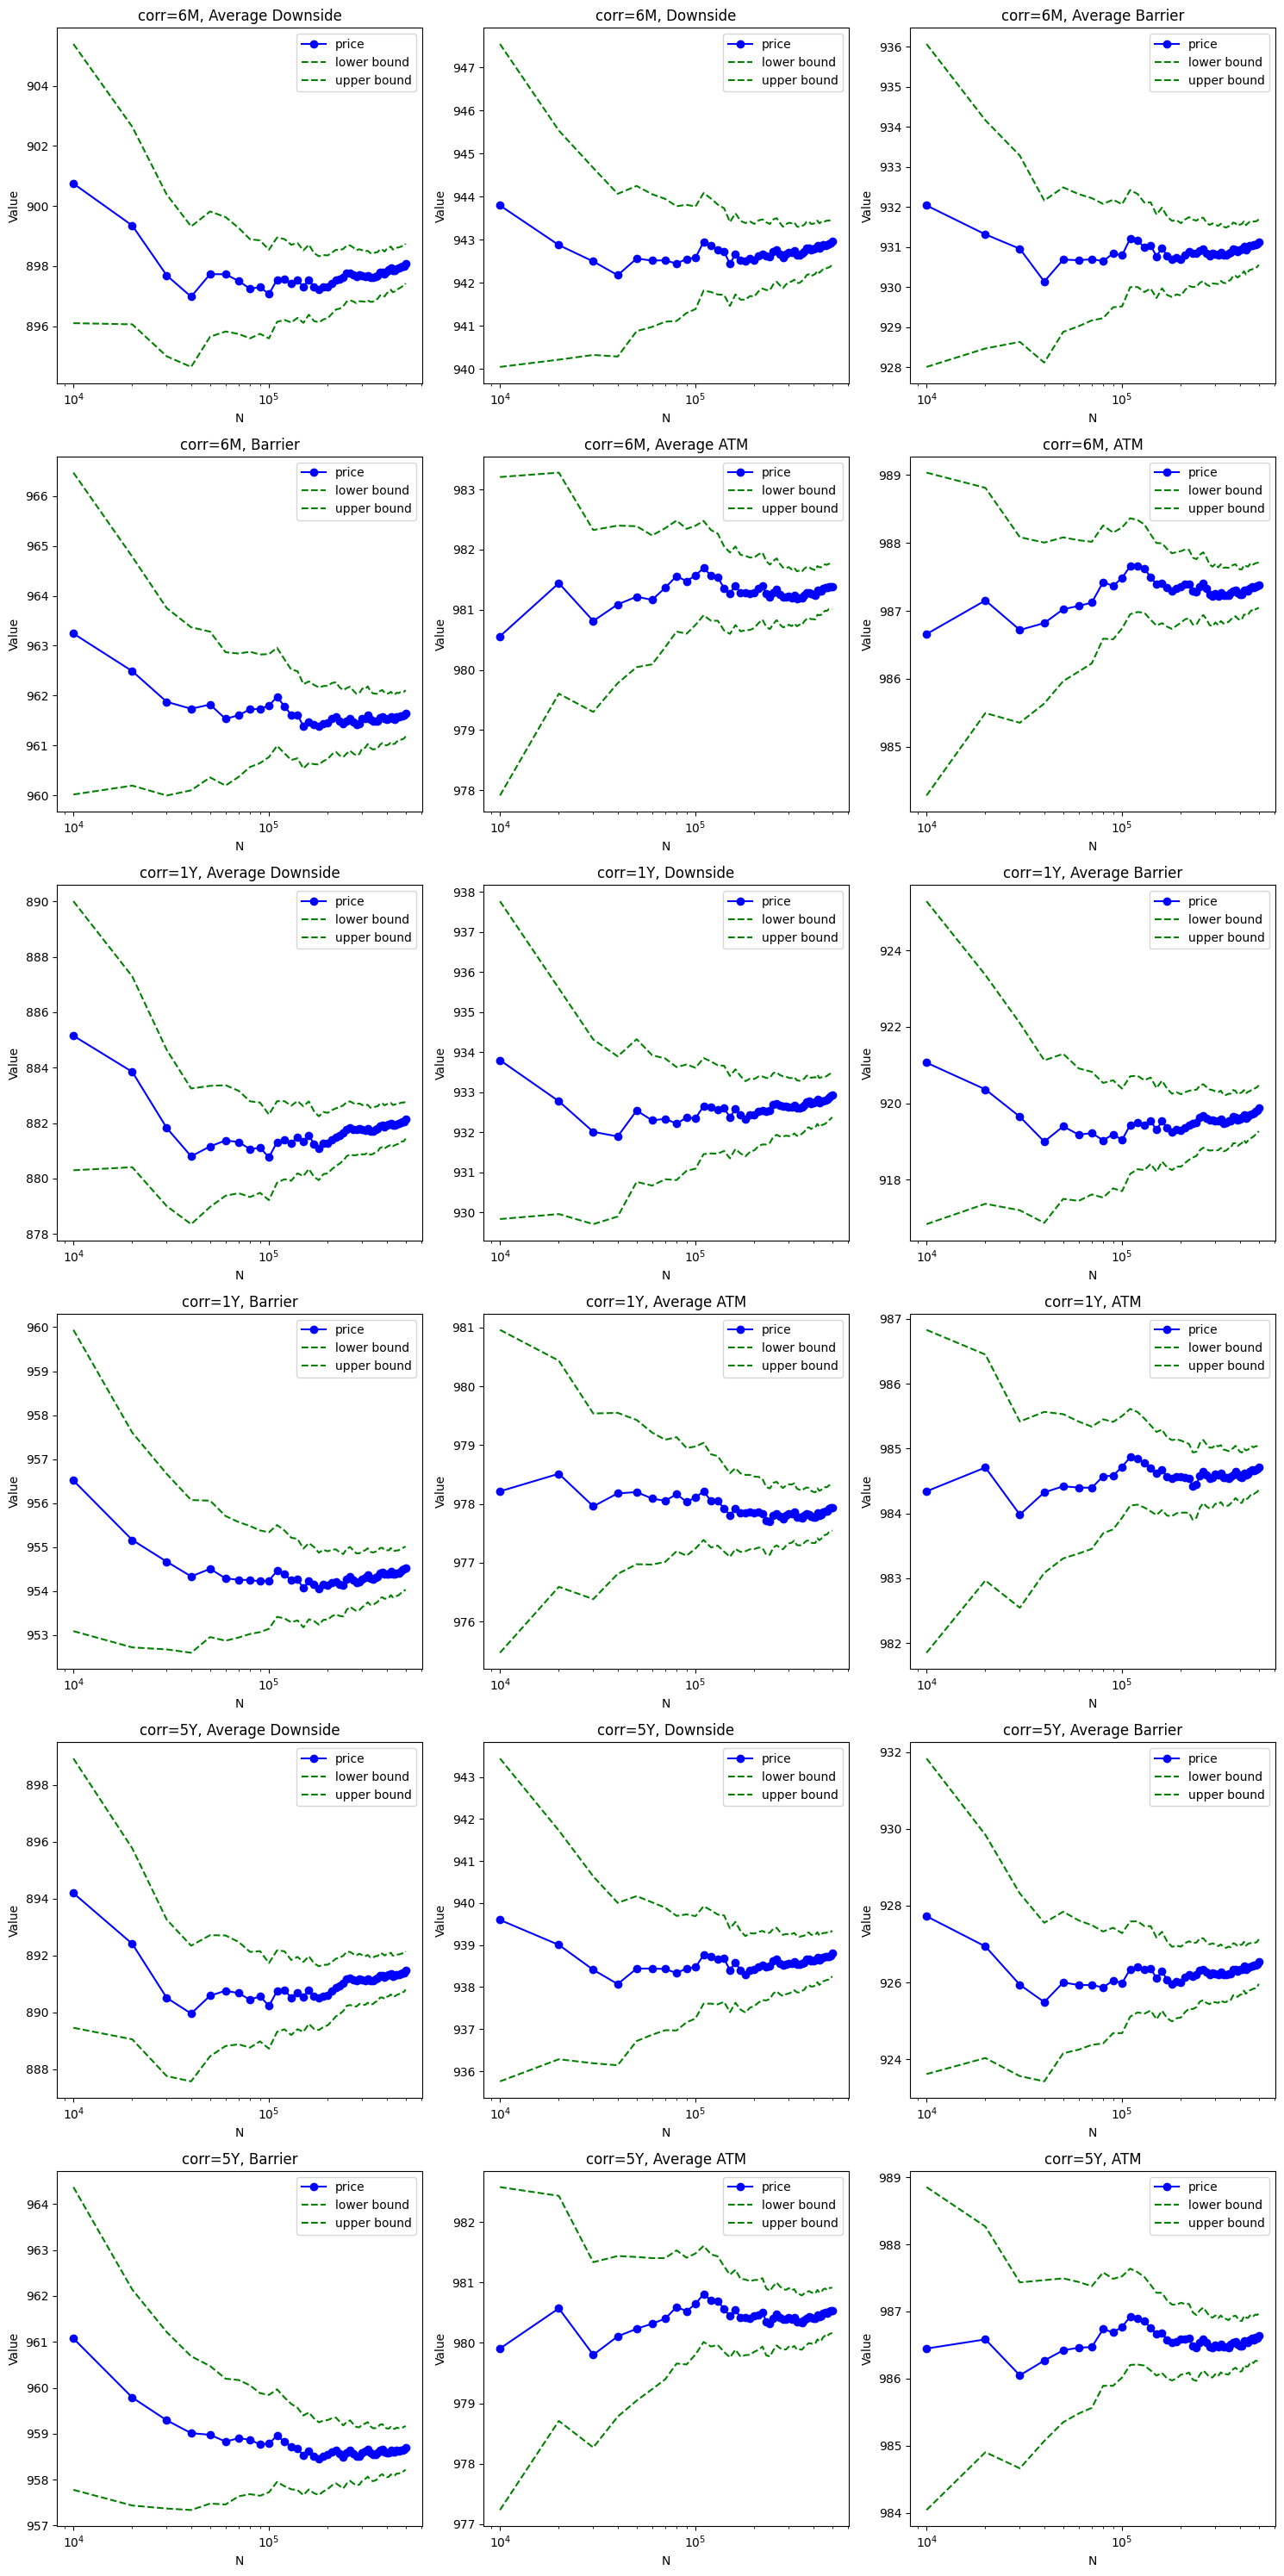

In [13]:
n = 1
plt.figure(figsize=(15, 30))
for corr in corr_list:
  for sigma in sigma_list:
    ds = df.query("corr == @corr and sigma == @sigma and basis == 'Legendre'")
    plt.subplot(6, 3, n)
    plt.plot(ds['N'], ds['value'], 'bo-', label='price')
    plt.plot(ds['N'], ds['value']-1.96*ds['std'], 'g--', label='lower bound')
    plt.plot(ds['N'], ds['value']+1.96*ds['std'], 'g--', label='upper bound')
    plt.xlabel('N')
    plt.ylabel('Value')
    plt.xscale('log')
    plt.legend()
    plt.title(f'corr={corr}, {sigma}')
    n += 1
# plt.suptitle('Sensitivity to Number of Simulation Paths')
plt.tight_layout()
plt.show()

## Correlation

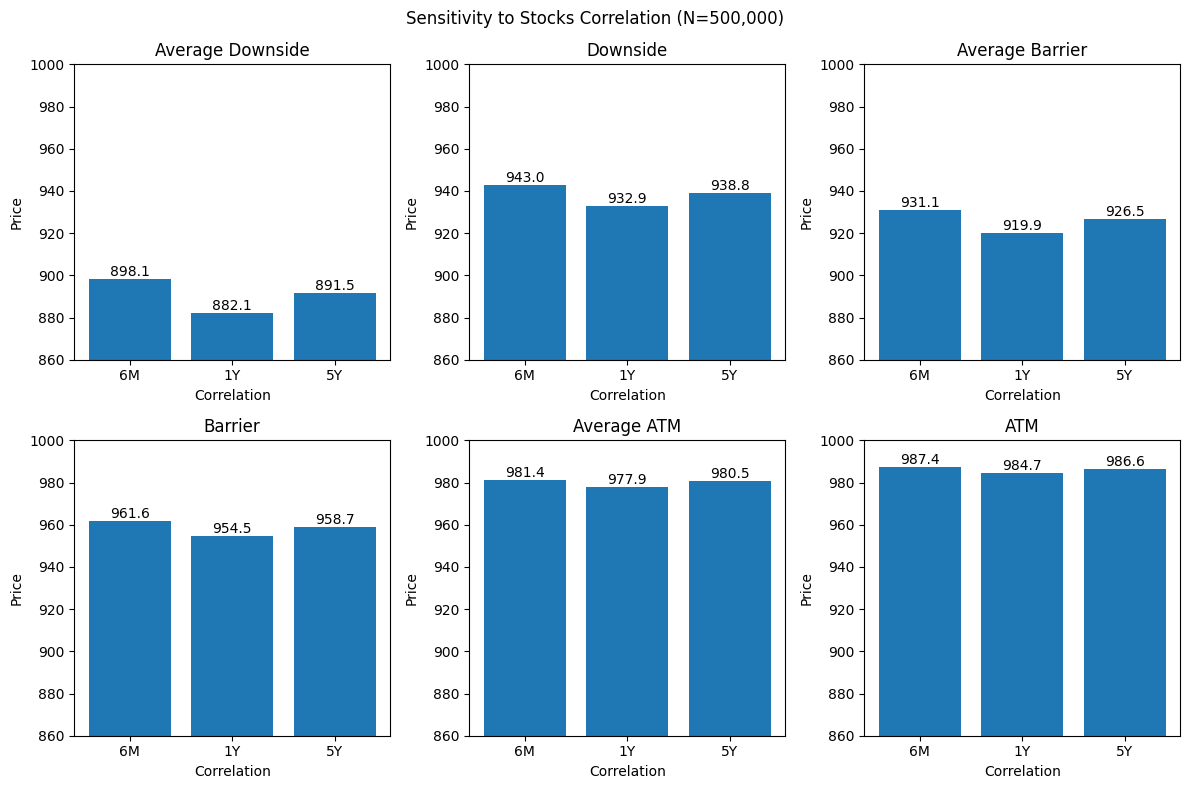

In [ ]:
n = 1
plt.figure(figsize=(12, 8))
plt.suptitle('Sensitivity to Stocks Correlation (N=500,000)')
for sigma in sigma_list:
  ds = df.query("N == 500000 and sigma == @sigma and basis == 'Legendre'")
  plt.subplot(2, 3, n)
  bars = plt.bar(ds['corr'], ds['value'])
  for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, h, f"{h:.1f}",
        ha='center', va='bottom', fontsize=10)
  plt.ylim(860, 1000)
  plt.xlabel('Correlation')
  plt.ylabel('Price')
  plt.title(f'{sigma}')
  n += 1
plt.tight_layout()
plt.show()

## Volatility

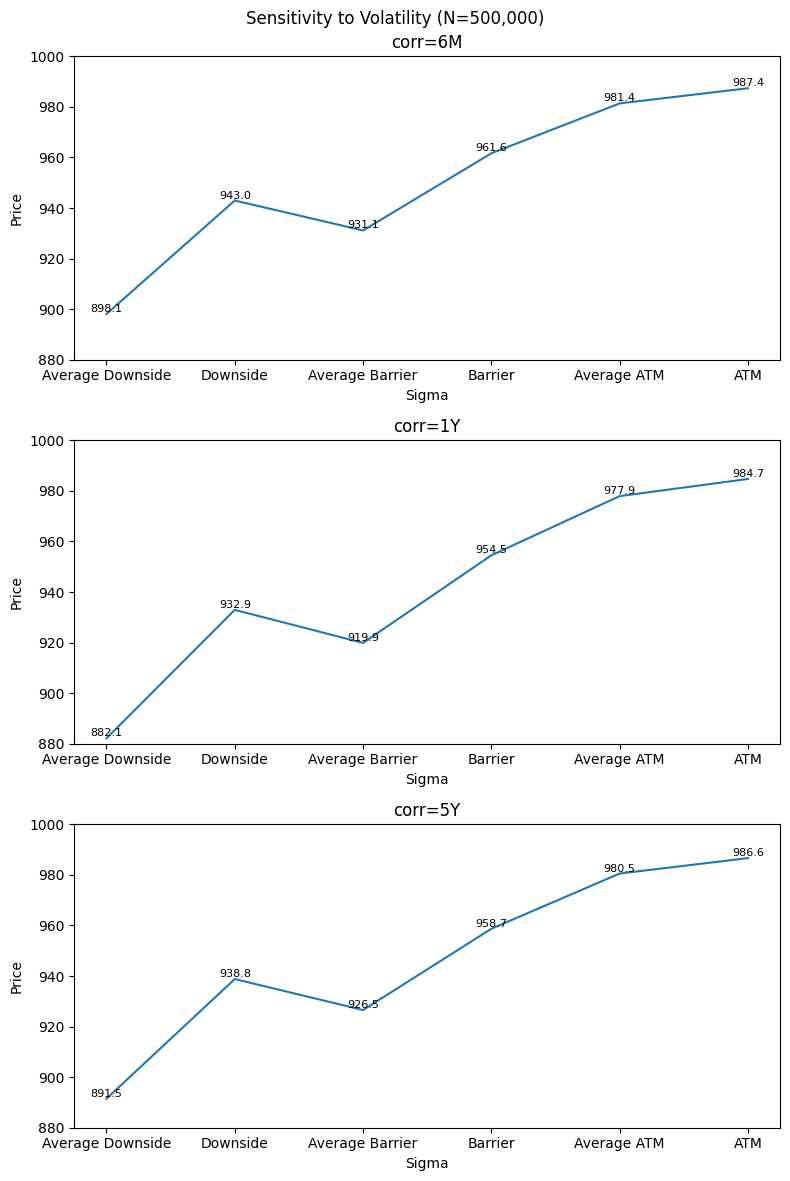

In [ ]:
n = 1
plt.figure(figsize=(8, 12))
plt.suptitle('Sensitivity to Volatility (N=500,000)')
for corr in corr_list:
  ds = df.query("N == 500000 and corr == @corr and basis == 'Legendre'")
  plt.subplot(3, 1, n)
  plt.plot(ds['sigma'], ds['value'])
  for x, y in zip(ds['sigma'], ds['value']):
    plt.text(x, y, f"{y:.1f}", ha='center', va='bottom', fontsize=8)
  plt.ylim(880, 1000)
  plt.xlabel('Sigma')
  plt.ylabel('Price')
  plt.title(f'corr={corr}')
  n += 1
plt.tight_layout()
plt.show()